# AI013 Time Series Forecasting: Forecasting Monthly Disaster-Affected Population

## Introduction

This project focuses on time series forecasting using a disaster impact dataset. The dataset contains historical disaster event records, including event type, location, severity score, weather conditions, casualties, economic loss, and affected population.

The main aim of this project is to forecast the monthly number of people affected by disaster events. To make the dataset suitable for time series forecasting, the original event-level records are converted into monthly aggregated data. The forecasting target is the total affected population per month.

This type of forecasting can support emergency planning by helping decision-makers understand possible future disaster impact levels based on previous patterns.

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

Load the dataset

In [2]:
df = pd.read_csv("parent_disaster_dataset.csv")

df.head()

,hazard_event_id,integration_id,state,region,suburb,event_type,severity_score,severity_level,risk_category,start_time,duration_hours,temperature_c,rainfall_mm,humidity_pct,fatalities,injuries,economic_loss_million,affected_population
0,HZ_00001,eeb92602-6fe0-4ebb-819d-f7c443896216,Victoria,Melbourne Metro,Melbourne,bushfire,3.7,medium,low,2025-02-18T00:00:00+00:00,12,40.1,1.7,12.9,3,38,146.58,370
1,HZ_00002,8810dcdc-4ed9-4860-99b9-a39d6e839092,Victoria,Melbourne Metro,Melbourne,heatwave,5.9,medium,medium,2024-05-23T00:00:00+00:00,6,51.2,0.0,10.3,15,37,103.78,590
2,HZ_00003,a5ad271c-f785-436b-818d-c45ec803da53,Victoria,Melbourne Metro,Melbourne,flood,4.6,medium,low,2024-07-12T00:00:00+00:00,72,23.9,81.5,87.8,12,59,15.15,459
3,HZ_00004,08501bb6-1113-47f8-9c7f-7bde0e085169,New South Wales,Hunter Region,Newcastle,flood,8.0,high,high,2025-08-10T00:00:00+00:00,24,23.0,101.5,71.1,17,112,44.47,800
4,HZ_00005,2ac6f328-9cfc-45db-b447-dacf947438b5,New South Wales,Greater Sydney,Parramatta,bushfire,5.0,medium,medium,2024-10-06T00:00:00+00:00,48,37.0,1.2,NaN,18,99,17.31,500


## Dataset Overview

The dataset is first checked to understand its structure, columns, data types, missing values, and date range. This step helps confirm whether the dataset is suitable for time series forecasting.

In [3]:
df.shape

(58, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   hazard_event_id        58 non-null     object 
 1   integration_id         58 non-null     object 
 2   state                  58 non-null     object 
 3   region                 58 non-null     object 
 4   suburb                 58 non-null     object 
 5   event_type             58 non-null     object 
 6   severity_score         58 non-null     float64
 7   severity_level         58 non-null     object 
 8   risk_category          58 non-null     object 
 9   start_time             58 non-null     object 
 10  duration_hours         58 non-null     int64  
 11  temperature_c          58 non-null     float64
 12  rainfall_mm            58 non-null     float64
 13  humidity_pct           56 non-null     float64
 14  fatalities             58 non-null     int64  
 15  injuries

In [5]:
df.isnull().sum()

,0
hazard_event_id,0
integration_id,0
state,0
region,0
suburb,0
event_type,0
severity_score,0
severity_level,0
risk_category,0
start_time,0


In [6]:
df.describe()

,severity_score,duration_hours,temperature_c,rainfall_mm,humidity_pct,fatalities,injuries,economic_loss_million,affected_population
count,58.000000,58.000000,58.000000,58.000000,56.000000,58.000000,58.000000,58.000000,58.000000
mean,6.084483,34.551724,31.884483,41.998276,41.564286,14.482759,76.206897,156.997414,608.293103
std,2.164369,22.374149,12.308060,71.899519,30.746325,10.352119,38.155158,114.683705,216.456309
min,2.100000,6.000000,10.200000,0.000000,5.000000,1.000000,17.000000,7.030000,210.000000
25%,4.525000,12.000000,21.475000,1.000000,12.650000,6.000000,44.750000,59.127500,452.250000
50%,5.500000,24.000000,28.100000,2.950000,38.200000,12.500000,64.500000,150.985000,550.000000
75%,7.750000,48.000000,42.250000,45.225000,69.800000,20.000000,99.750000,226.952500,775.000000
max,10.000000,72.000000,52.000000,338.100000,98.900000,46.000000,179.000000,476.470000,1000.000000


## Date Conversion

The start_time column represents the date of each disaster event. This column is converted into datetime format so that the data can be grouped and analysed over time.

In [7]:
df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")

df["start_time"].min(), df["start_time"].max()

(Timestamp('2024-01-02 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-17 00:00:00+0000', tz='UTC'))

## Monthly Time Series Preparation

The original dataset contains individual disaster event records. Since time series forecasting requires observations over regular time intervals, the data is aggregated by month.

The monthly dataset includes the number of disaster events, total affected population, average severity score, total economic loss, average weather conditions, total fatalities, and total injuries.

In [8]:
monthly_df = df.set_index("start_time").resample("MS").agg(
    event_count=("hazard_event_id", "count"),
    total_affected_population=("affected_population", "sum"),
    avg_severity_score=("severity_score", "mean"),
    total_economic_loss_million=("economic_loss_million", "sum"),
    avg_temperature_c=("temperature_c", "mean"),
    avg_rainfall_mm=("rainfall_mm", "mean"),
    avg_humidity_pct=("humidity_pct", "mean"),
    total_fatalities=("fatalities", "sum"),
    total_injuries=("injuries", "sum")
).reset_index()

monthly_df.head()

,start_time,event_count,total_affected_population,avg_severity_score,total_economic_loss_million,avg_temperature_c,avg_rainfall_mm,avg_humidity_pct,total_fatalities,total_injuries
0,2024-01-01 00:00:00+00:00,3,2380,7.933333,617.67,43.966667,1.10,6.00,48,345
1,2024-02-01 00:00:00+00:00,2,920,4.600000,194.05,29.350000,22.75,30.45,31,151
2,2024-03-01 00:00:00+00:00,4,2630,6.575000,563.14,38.550000,49.70,28.95,74,269
3,2024-04-01 00:00:00+00:00,2,730,3.650000,213.14,18.150000,6.20,47.90,6,89
4,2024-05-01 00:00:00+00:00,2,1350,6.750000,463.94,32.700000,0.65,34.55,17,168


Because one month may have no event, some average columns may become missing.

In [9]:
monthly_df.isnull().sum()

,0
start_time,0
event_count,0
total_affected_population,0
avg_severity_score,1
total_economic_loss_million,0
avg_temperature_c,1
avg_rainfall_mm,1
avg_humidity_pct,1
total_fatalities,0
total_injuries,0


In [10]:
monthly_df["avg_severity_score"] = monthly_df["avg_severity_score"].fillna(0)
monthly_df["avg_temperature_c"] = monthly_df["avg_temperature_c"].fillna(method="ffill")
monthly_df["avg_rainfall_mm"] = monthly_df["avg_rainfall_mm"].fillna(0)
monthly_df["avg_humidity_pct"] = monthly_df["avg_humidity_pct"].fillna(method="ffill")

monthly_df.isnull().sum()

/tmp/ipykernel_4364/3328947616.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_df["avg_temperature_c"] = monthly_df["avg_temperature_c"].fillna(method="ffill")
/tmp/ipykernel_4364/3328947616.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_df["avg_humidity_pct"] = monthly_df["avg_humidity_pct"].fillna(method="ffill")


,0
start_time,0
event_count,0
total_affected_population,0
avg_severity_score,0
total_economic_loss_million,0
avg_temperature_c,0
avg_rainfall_mm,0
avg_humidity_pct,0
total_fatalities,0
total_injuries,0


View final monthly dataset

In [11]:
monthly_df

,start_time,event_count,total_affected_population,avg_severity_score,total_economic_loss_million,avg_temperature_c,avg_rainfall_mm,avg_humidity_pct,total_fatalities,total_injuries
0,2024-01-01 00:00:00+00:00,3,2380,7.933333,617.67,43.966667,1.100000,6.000000,48,345
1,2024-02-01 00:00:00+00:00,2,920,4.600000,194.05,29.350000,22.750000,30.450000,31,151
2,2024-03-01 00:00:00+00:00,4,2630,6.575000,563.14,38.550000,49.700000,28.950000,74,269
3,2024-04-01 00:00:00+00:00,2,730,3.650000,213.14,18.150000,6.200000,47.900000,6,89
4,2024-05-01 00:00:00+00:00,2,1350,6.750000,463.94,32.700000,0.650000,34.550000,17,168
5,2024-06-01 00:00:00+00:00,0,0,0.000000,0.00,32.700000,0.000000,34.550000,0,0
6,2024-07-01 00:00:00+00:00,2,868,4.350000,114.47,20.950000,65.350000,82.950000,19,128
7,2024-08-01 00:00:00+00:00,1,750,7.500000,163.53,22.000000,32.100000,43.200000,12,64
8,2024-09-01 00:00:00+00:00,4,2669,6.675000,565.29,28.075000,10.250000,27.000000,69,330
9,2024-10-01 00:00:00+00:00,2,1410,7.050000,233.90,27.250000,81.750000,76.300000,56,250


In [12]:
monthly_df.to_csv("monthly_disaster_timeseries.csv", index=False)

## Time Series Visualisation

The target variable for this project is the total affected population per month. Plotting this variable helps identify changes, spikes, drops, and possible patterns over time.

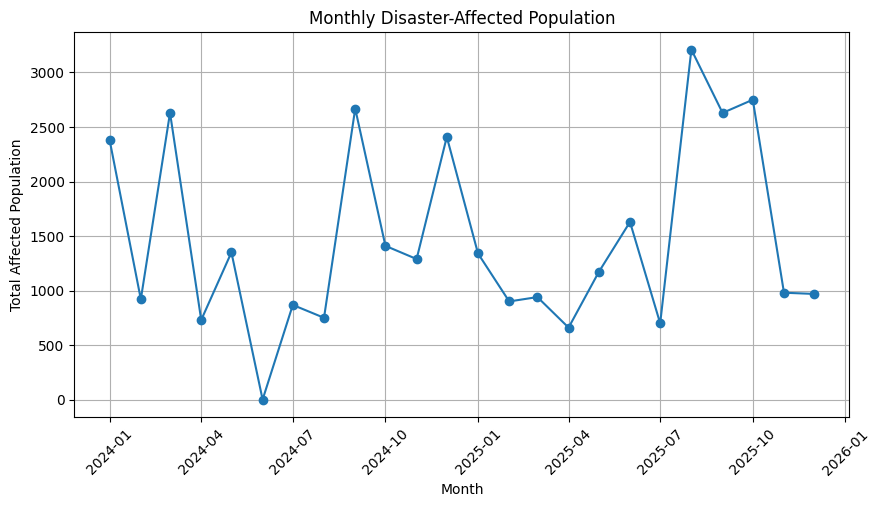

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_df["start_time"], monthly_df["total_affected_population"], marker="o")
plt.title("Monthly Disaster-Affected Population")
plt.xlabel("Month")
plt.ylabel("Total Affected Population")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Exploratory Data Analysis

After preparing the monthly time series dataset, exploratory data analysis is performed to understand the behaviour of disaster impact over time. This section focuses on the monthly affected population, number of disaster events, severity score, and economic loss.

The purpose of this step is to identify visible trends, sudden spikes, and possible relationships between disaster frequency, severity, and population impact.

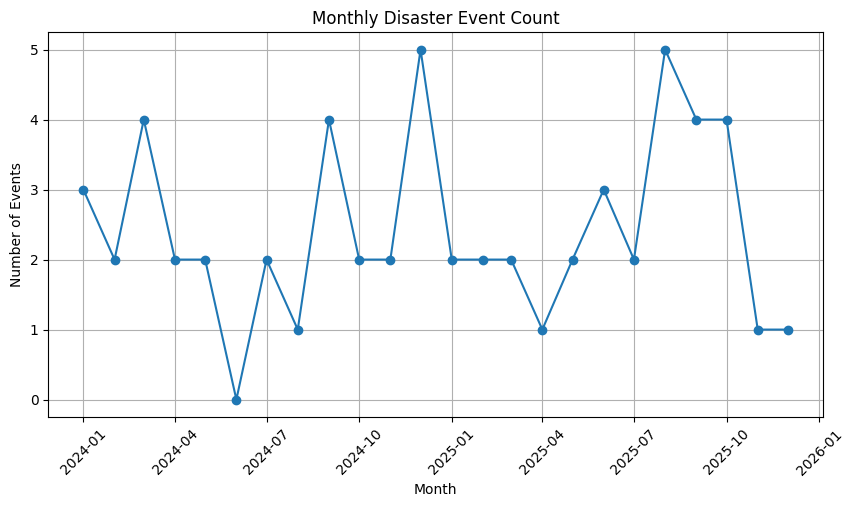

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_df["start_time"], monthly_df["event_count"], marker="o")
plt.title("Monthly Disaster Event Count")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The monthly event count shows how many disaster events were recorded in each month. Some months have more events than others, which suggests that disaster activity is not evenly distributed across the full period.

Plot average severity score

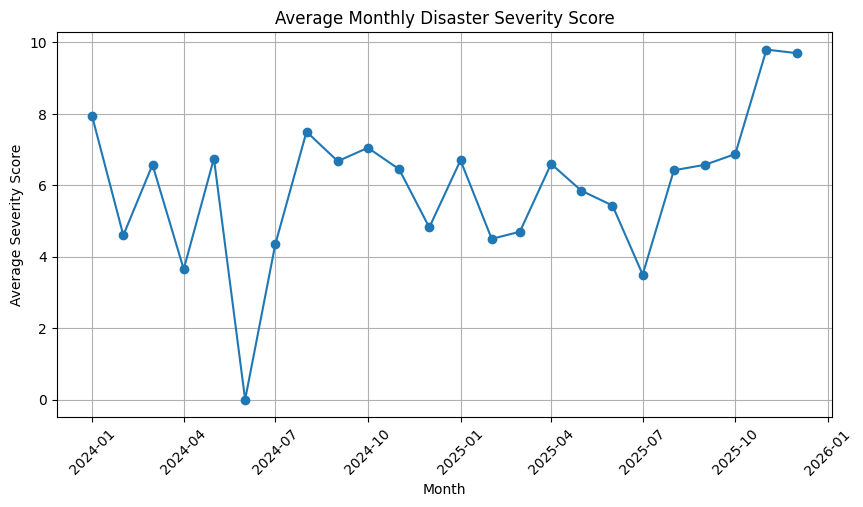

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_df["start_time"], monthly_df["avg_severity_score"], marker="o")
plt.title("Average Monthly Disaster Severity Score")
plt.xlabel("Month")
plt.ylabel("Average Severity Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The average monthly severity score helps show whether disaster events were generally mild, moderate, or severe in different months. Higher severity months may also be linked with higher affected population or larger economic loss.

Plot economic loss

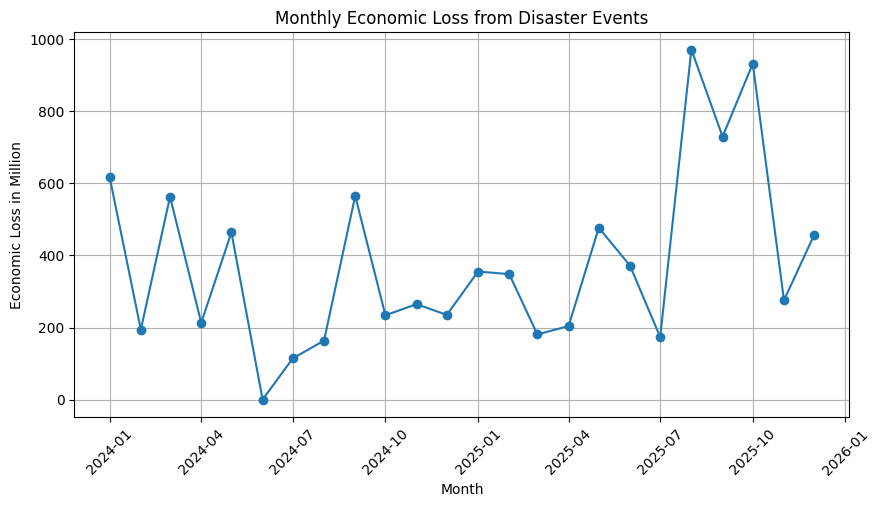

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_df["start_time"], monthly_df["total_economic_loss_million"], marker="o")
plt.title("Monthly Economic Loss from Disaster Events")
plt.xlabel("Month")
plt.ylabel("Economic Loss in Million")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The economic loss trend shows the estimated financial impact of disaster events across months. Some months may show sudden increases because of high-impact events such as severe floods, bushfires, or heatwaves.

Correlation check

In [18]:
correlation_cols = [
    "event_count",
    "total_affected_population",
    "avg_severity_score",
    "total_economic_loss_million",
    "avg_temperature_c",
    "avg_rainfall_mm",
    "avg_humidity_pct",
    "total_fatalities",
    "total_injuries"
]

monthly_df[correlation_cols].corr()

,event_count,total_affected_population,avg_severity_score,total_economic_loss_million,avg_temperature_c,avg_rainfall_mm,avg_humidity_pct,total_fatalities,total_injuries
event_count,1.000000,0.930598,0.117458,0.701722,0.148979,-0.248162,-0.206980,0.786149,0.828944
total_affected_population,0.930598,1.000000,0.364969,0.851117,0.255817,-0.164408,-0.225434,0.869687,0.923395
avg_severity_score,0.117458,0.364969,1.000000,0.448051,0.286326,0.342602,0.016671,0.362793,0.372941
total_economic_loss_million,0.701722,0.851117,0.448051,1.000000,0.188318,-0.120619,-0.177847,0.654863,0.829216
avg_temperature_c,0.148979,0.255817,0.286326,0.188318,1.000000,-0.322612,-0.735218,0.118657,0.192760
avg_rainfall_mm,-0.248162,-0.164408,0.342602,-0.120619,-0.322612,1.000000,0.767479,0.043821,-0.126305
avg_humidity_pct,-0.206980,-0.225434,0.016671,-0.177847,-0.735218,0.767479,1.000000,0.014197,-0.173563
total_fatalities,0.786149,0.869687,0.362793,0.654863,0.118657,0.043821,0.014197,1.000000,0.803362
total_injuries,0.828944,0.923395,0.372941,0.829216,0.192760,-0.126305,-0.173563,0.803362,1.000000


The correlation table gives a basic understanding of how the monthly disaster-related variables are associated with each other. The main focus is on how variables such as event count, severity score, injuries, fatalities, and economic loss relate to the total affected population.

## Train-Test Split

For time series forecasting, the data should not be randomly split because the order of observations matters. The earlier months are used for training, while the most recent months are used for testing.

In this project, the final six months are kept as the test set. This allows the model to be trained on past observations and then evaluated on future unseen months.

In [19]:
series = monthly_df[["start_time", "total_affected_population"]].copy()
series = series.set_index("start_time")

train = series.iloc[:-6]
test = series.iloc[-6:]

print("Training data:")
print(train)

print("\nTesting data:")
print(test)

Training data:
                           total_affected_population
start_time                                          
2024-01-01 00:00:00+00:00                       2380
2024-02-01 00:00:00+00:00                        920
2024-03-01 00:00:00+00:00                       2630
2024-04-01 00:00:00+00:00                        730
2024-05-01 00:00:00+00:00                       1350
2024-06-01 00:00:00+00:00                          0
2024-07-01 00:00:00+00:00                        868
2024-08-01 00:00:00+00:00                        750
2024-09-01 00:00:00+00:00                       2669
2024-10-01 00:00:00+00:00                       1410
2024-11-01 00:00:00+00:00                       1289
2024-12-01 00:00:00+00:00                       2409
2025-01-01 00:00:00+00:00                       1340
2025-02-01 00:00:00+00:00                        900
2025-03-01 00:00:00+00:00                        940
2025-04-01 00:00:00+00:00                        660
2025-05-01 00:00:00+00:00      

Plot train and test:

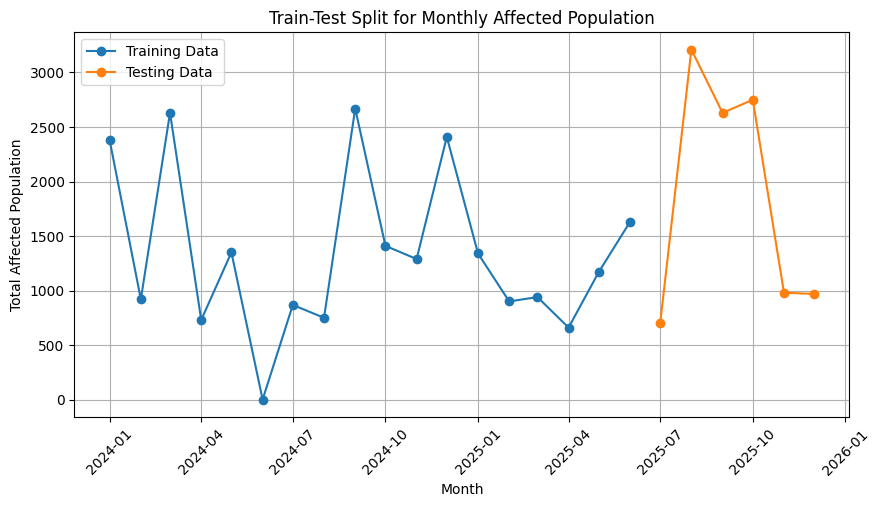

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["total_affected_population"], marker="o", label="Training Data")
plt.plot(test.index, test["total_affected_population"], marker="o", label="Testing Data")
plt.title("Train-Test Split for Monthly Affected Population")
plt.xlabel("Month")
plt.ylabel("Total Affected Population")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation Metrics

The forecasting models are evaluated using common regression-based time series metrics.

Mean Absolute Error measures the average size of prediction errors. Root Mean Squared Error gives more weight to larger errors. Mean Absolute Percentage Error shows the average percentage error, but it must be used carefully when actual values are close to zero.

In [21]:
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    actual = np.array(actual)
    predicted = np.array(predicted)

    non_zero = actual != 0
    if non_zero.sum() > 0:
        mape = np.mean(np.abs((actual[non_zero] - predicted[non_zero]) / actual[non_zero])) * 100
    else:
        mape = np.nan

    return mae, rmse, mape

## Baseline Forecasting Model

A baseline model is created first so that more advanced models can be compared against a simple reference point. In this baseline approach, the last observed training value is repeated for all future test months.

This method is simple, but it is useful because any advanced forecasting model should ideally perform better than this baseline.

In [22]:
last_train_value = train["total_affected_population"].iloc[-1]

baseline_predictions = [last_train_value] * len(test)

baseline_mae, baseline_rmse, baseline_mape = evaluate_forecast(
    test["total_affected_population"],
    baseline_predictions
)

print("Baseline Forecast Results")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape)

Baseline Forecast Results
MAE: 990.1666666666666
RMSE: 1039.062317669157
MAPE: 65.90606742465694


Plot baseline predictions

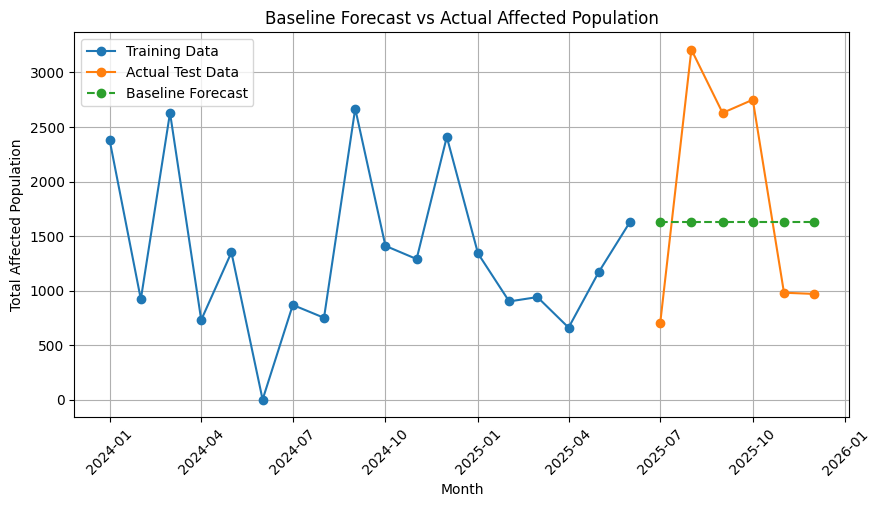

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["total_affected_population"], marker="o", label="Training Data")
plt.plot(test.index, test["total_affected_population"], marker="o", label="Actual Test Data")
plt.plot(test.index, baseline_predictions, marker="o", linestyle="--", label="Baseline Forecast")
plt.title("Baseline Forecast vs Actual Affected Population")
plt.xlabel("Month")
plt.ylabel("Total Affected Population")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

The baseline forecast gives a simple comparison point. Since it only repeats the last known value, it does not capture changes, spikes, or drops in affected population. However, it is useful for checking whether more advanced models provide better forecasting performance.

## Moving Average Forecasting Model

The moving average model uses the average of recent observations to make future predictions. In this project, a three-month moving average is used. This approach smooths short-term fluctuations and gives a simple estimate based on recent disaster impact levels.

In [25]:
moving_average_value = train["total_affected_population"].tail(3).mean()

moving_average_predictions = [moving_average_value] * len(test)

ma_mae, ma_rmse, ma_mape = evaluate_forecast(
    test["total_affected_population"],
    moving_average_predictions
)

print("Moving Average Forecast Results")
print("MAE:", ma_mae)
print("RMSE:", ma_rmse)
print("MAPE:", ma_mape)

Moving Average Forecast Results
MAE: 990.1666666666666
RMSE: 1240.3047340606797
MAPE: 46.648063683627655


Plot moving average predictions:

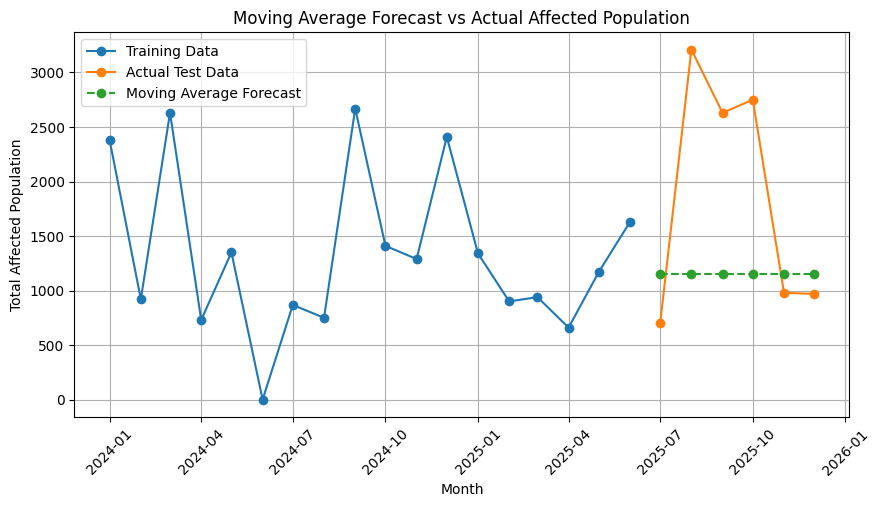

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["total_affected_population"], marker="o", label="Training Data")
plt.plot(test.index, test["total_affected_population"], marker="o", label="Actual Test Data")
plt.plot(test.index, moving_average_predictions, marker="o", linestyle="--", label="Moving Average Forecast")
plt.title("Moving Average Forecast vs Actual Affected Population")
plt.xlabel("Month")
plt.ylabel("Total Affected Population")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

The moving average forecast is slightly more flexible than the baseline model because it uses recent values instead of only the last observation. However, it still produces a constant forecast for all test months and may not capture sudden changes in disaster impact.

## ARIMA Forecasting Model

## ARIMA Forecasting Model

ARIMA is a common statistical model used for time series forecasting. It uses past values and past errors to predict future observations. Since the dataset is small, a simple ARIMA configuration is used instead of testing many complex combinations.

The model is trained on the training portion of the monthly affected population series and then used to forecast the test period.

In [28]:
from statsmodels.tsa.arima.model import ARIMA

In [29]:
arima_model = ARIMA(train["total_affected_population"], order=(1, 1, 1))
arima_result = arima_model.fit()

arima_predictions = arima_result.forecast(steps=len(test))

arima_mae, arima_rmse, arima_mape = evaluate_forecast(
    test["total_affected_population"],
    arima_predictions
)

print("ARIMA Forecast Results")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA Forecast Results
MAE: 961.3453040269729
RMSE: 1053.5773332302688
MAPE: 56.98154622777536


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Plot ARIMA forecast:

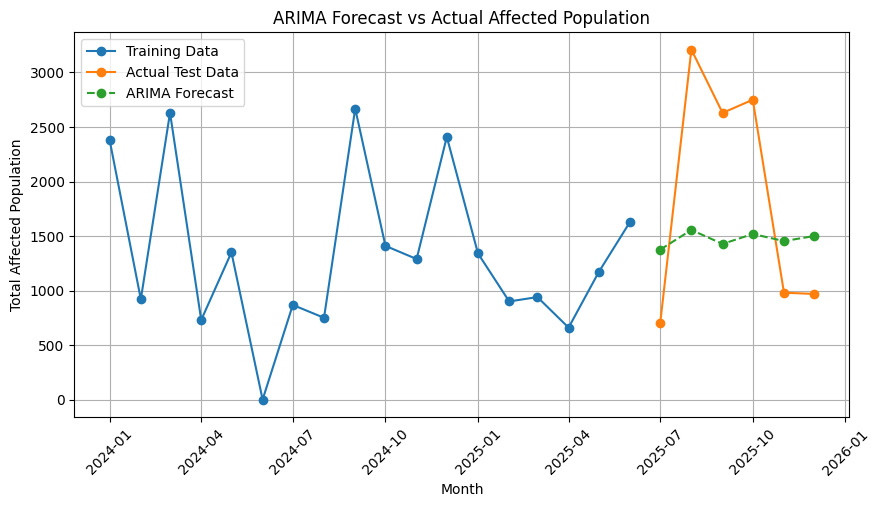

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train["total_affected_population"], marker="o", label="Training Data")
plt.plot(test.index, test["total_affected_population"], marker="o", label="Actual Test Data")
plt.plot(test.index, arima_predictions, marker="o", linestyle="--", label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual Affected Population")
plt.xlabel("Month")
plt.ylabel("Total Affected Population")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

The ARIMA model attempts to learn patterns from the historical affected population values. Since the dataset only contains a limited number of monthly observations, the ARIMA results should be interpreted carefully. The model can still provide a useful comparison against the baseline and moving average methods.

## Model Comparison

The forecasting models are compared using MAE, RMSE, and MAPE. The model with lower error values performs better on the test data. Since this dataset is small, the comparison should be treated as an initial experiment rather than a final production-level forecasting result.

In [31]:
results_df = pd.DataFrame({
    "Model": ["Baseline", "Moving Average", "ARIMA"],
    "MAE": [baseline_mae, ma_mae, arima_mae],
    "RMSE": [baseline_rmse, ma_rmse, arima_rmse],
    "MAPE": [baseline_mape, ma_mape, arima_mape]
})

results_df

,Model,MAE,RMSE,MAPE
0,Baseline,990.166667,1039.062318,65.906067
1,Moving Average,990.166667,1240.304734,46.648064
2,ARIMA,961.345304,1053.577333,56.981546


Plot comparison:

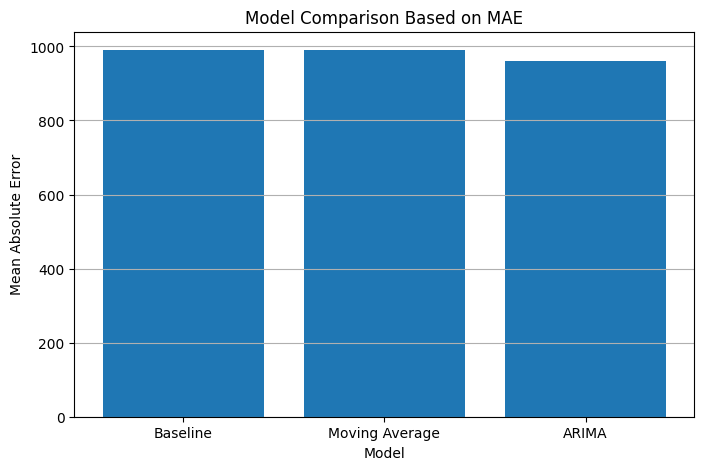

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.grid(axis="y")
plt.show()

The model comparison shows which forecasting method performed best on the test data. A lower MAE means the model made smaller average prediction errors. If ARIMA performs better than the baseline models, it suggests that using a time series model adds value. If the baseline or moving average performs better, it may be because the dataset is too small or too irregular for ARIMA to learn a stable pattern.

## Future Forecast

After comparing the models, the selected forecasting approach is used to predict future disaster-affected population. The forecast is made for the next six months after the available dataset period.

This future forecast can provide a basic estimate of possible disaster impact levels, but it should not be treated as a guaranteed prediction. Disaster events are influenced by many external factors, so the results should be interpreted as a planning support tool rather than an exact forecast.

Use ARIMA for future forecast:

In [33]:
final_model = ARIMA(series["total_affected_population"], order=(1, 1, 1))
final_result = final_model.fit()

future_steps = 6
future_forecast = final_result.forecast(steps=future_steps)

future_dates = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=future_steps,
    freq="MS"
)

future_df = pd.DataFrame({
    "month": future_dates,
    "forecasted_affected_population": future_forecast.values
})

future_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,month,forecasted_affected_population
0,2026-01-01 00:00:00+00:00,638.633206
1,2026-02-01 00:00:00+00:00,906.459480
2,2026-03-01 00:00:00+00:00,689.334411
3,2026-04-01 00:00:00+00:00,865.356333
4,2026-05-01 00:00:00+00:00,722.656473
5,2026-06-01 00:00:00+00:00,838.342348


Plot future forecast:

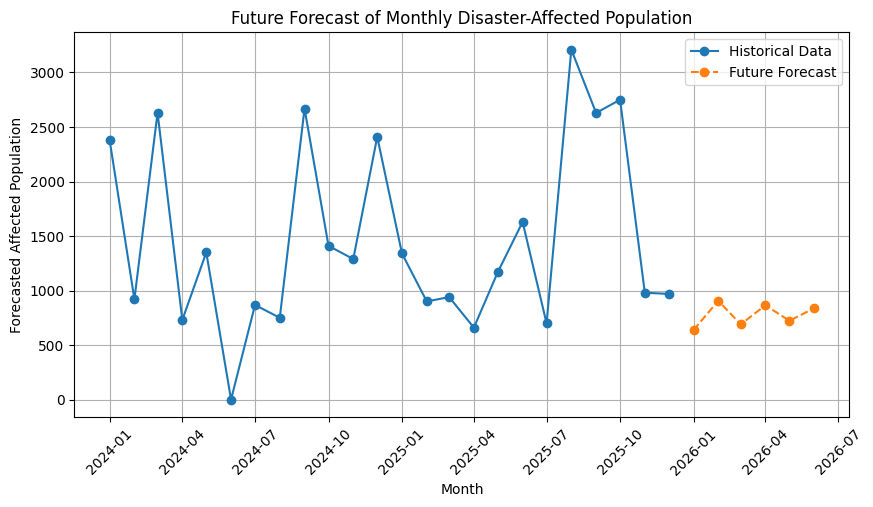

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(series.index, series["total_affected_population"], marker="o", label="Historical Data")
plt.plot(future_df["month"], future_df["forecasted_affected_population"], marker="o", linestyle="--", label="Future Forecast")
plt.title("Future Forecast of Monthly Disaster-Affected Population")
plt.xlabel("Month")
plt.ylabel("Forecasted Affected Population")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Save forecast output:

In [35]:
future_df.to_csv("future_affected_population_forecast.csv", index=False)

The future forecast provides an estimated affected population for the next six months. These results can be used as a simple planning reference for emergency response preparation, resource allocation, and risk monitoring.

## Conclusion

This project developed a time series forecasting workflow using a disaster impact dataset. The original data contained individual disaster event records, so it was first converted into monthly time series data. The main forecasting target was the total number of people affected by disaster events each month.

The analysis included data preparation, monthly aggregation, exploratory visualisation, train-test splitting, baseline forecasting, moving average forecasting, ARIMA modelling, model evaluation, and future prediction. The baseline model provided a simple reference point, while the moving average model used recent values to smooth short-term variation. The ARIMA model was used as the main time series forecasting method.

The results show that forecasting disaster impact is challenging because disaster events can be irregular and influenced by many external factors, such as weather, location, event type, and severity. Since the dataset is small, the model results should be interpreted carefully. A larger dataset covering more years would likely improve forecasting reliability.

Overall, this project demonstrates how disaster event data can be transformed into a time series forecasting problem. The forecasted affected population can support basic emergency planning by giving an early estimate of possible future impact levels.